In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

path = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\dataset_xgboost_ready.csv"
dataset = pd.read_csv(path)
dataset['Tanggal'] = pd.to_datetime(dataset['Tanggal'])

FEATURES = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
            'Rolling_Mean_4', 'Bulan', 'Pekan_Ke', 'Rata_Historis_SKU']
TARGET = 'Jumlah'

all_weeks = sorted(dataset['Tanggal'].unique())
print(f"Total minggu: {len(all_weeks)}")
print(f"Minggu ke-1 : {all_weeks[0]}")
print(f"Minggu ke-40: {all_weeks[39]}")
print(f"Minggu ke-41: {all_weeks[40]}")

Total minggu: 53
Minggu ke-1 : 2025-04-29 00:00:00
Minggu ke-40: 2026-01-27 00:00:00
Minggu ke-41: 2026-02-03 00:00:00


c:\Users\Arifi\Desktop\FORECASTING OBAT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Skema:
# week 1-35  = train_inner (untuk Optuna)
# week 36-40 = validation  (untuk Optuna)
# week 41-52 = future test  (untuk walk-forward, TIDAK disentuh Optuna)

train_inner = dataset[dataset['Tanggal'] < all_weeks[35]].copy()
val         = dataset[(dataset['Tanggal'] >= all_weeks[35]) &
                      (dataset['Tanggal'] < all_weeks[40])].copy()

X_inner, y_inner = train_inner[FEATURES], train_inner[TARGET]
X_val,   y_val   = val[FEATURES],         val[TARGET]

print(f"Train inner : {train_inner['Tanggal'].nunique()} minggu, {len(train_inner)} baris")
print(f"Validation  : {val['Tanggal'].nunique()} minggu, {len(val)} baris")
print(f"Future test : {len(all_weeks) - 40} minggu (untuk walk-forward)")

Train inner : 35 minggu, 6825 baris
Validation  : 5 minggu, 975 baris
Future test : 13 minggu (untuk walk-forward)


In [3]:
baseline = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
baseline.fit(X_inner, y_inner, verbose=False)

pred_b = baseline.predict(X_val)
rmse_b = np.sqrt(mean_squared_error(y_val, pred_b))
mae_b  = mean_absolute_error(y_val, pred_b)
r2_b = r2_score(y_val, pred_b)

print("=== BASELINE MODEL (evaluasi di validation set) ===")
print(f"RMSE : {rmse_b:.4f}")
print(f"MAE  : {mae_b:.4f}")
print(f"R2   : {r2_b:.4f}")

=== BASELINE MODEL (evaluasi di validation set) ===
RMSE : 16.9268
MAE  : 8.3021
R2   : -0.3590


In [4]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'random_state': 42
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_inner, y_inner, verbose=False)
    pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, pred))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest params: {study.best_params}")
print(f"Best RMSE (validation): {study.best_value:.4f}")

Best trial: 23. Best value: 12.233: 100%|██████████| 30/30 [00:14<00:00,  2.13it/s] 


Best params: {'n_estimators': 54, 'max_depth': 4, 'learning_rate': 0.02920800332847783, 'subsample': 0.7089419413107613, 'colsample_bytree': 0.6488924472027123, 'reg_lambda': 5.698905680560664, 'reg_alpha': 0.012447407019173694}
Best RMSE (validation): 12.2330


In [5]:
# Setelah hyperparameter dikunci, latih ulang dengan 40 minggu penuh
train_full = dataset[dataset['Tanggal'] < all_weeks[40]].copy()
X_full, y_full = train_full[FEATURES], train_full[TARGET]

best_params = study.best_params
best_params['random_state'] = 42

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_full, y_full, verbose=False)

# Evaluasi di validation set untuk komparasi dengan baseline
pred_f = final_model.predict(X_val)
rmse_f = np.sqrt(mean_squared_error(y_val, pred_f))
mae_f  = mean_absolute_error(y_val, pred_f)
r2_f  = r2_score(y_val, pred_f)

print("=== BASELINE vs FINAL (di validation set) ===")
print(f"{'Metrik':<8} {'Baseline':>10} {'Final':>10}")
print(f"{'RMSE':<8} {rmse_b:>10.4f} {rmse_f:>10.4f}")
print(f"{'MAE':<8} {mae_b:>10.4f} {mae_f:>10.4f}")
print(f"{'R2':<8} {r2_b:>10.4f} {r2_f:>10.4f}")

joblib.dump(final_model, r'C:\Users\Arifi\Desktop\FORECASTING OBAT\models\xgboost_best_model.joblib')
pd.DataFrame([best_params]).to_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\best_params.csv', index=False)
print("\nModel tersimpan: xgboost_best_model.joblib")

=== BASELINE vs FINAL (di validation set) ===
Metrik     Baseline      Final
RMSE        16.9268    11.4818
MAE          8.3021     6.1607
R2          -0.3590     0.3747

Model tersimpan: xgboost_best_model.joblib


            Fitur  Importance
Rata_Historis_SKU    0.356957
   Rolling_Mean_4    0.344179
            Lag_2    0.089551
            Lag_1    0.078886
            Lag_4    0.047926
            Bulan    0.030627
         Pekan_Ke    0.028789
            Lag_3    0.023084


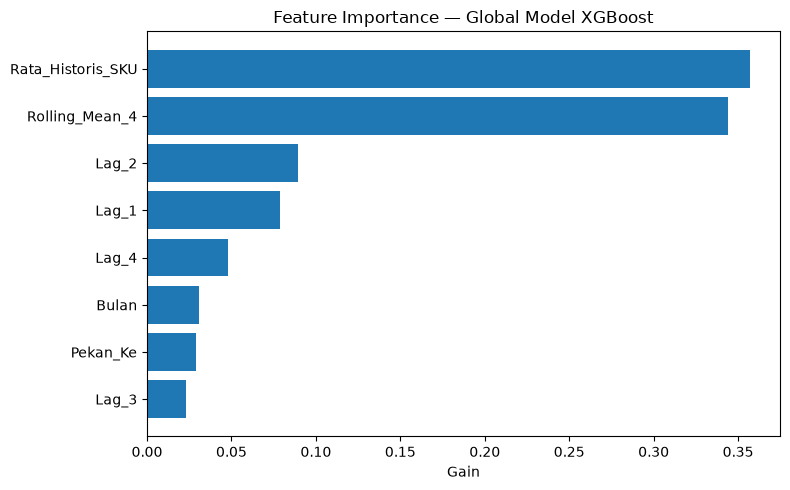

In [6]:
import matplotlib.pyplot as plt

fi = pd.DataFrame({
    'Fitur': FEATURES,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(fi.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(fi['Fitur'][::-1], fi['Importance'][::-1])
plt.title('Feature Importance — Global Model XGBoost')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()